# Анализ сохранённых CSV
Этот сценарий не запускает модель: входом служит базовый CSV.

Row,source,rows,peak,time_peak,R_T
,String,Int64,Int64,Float64,Int64
1,sir_N1000_b0.05_c10.0_g0.25_seed1234_T40.0.csv,1514,175,21.4162,745


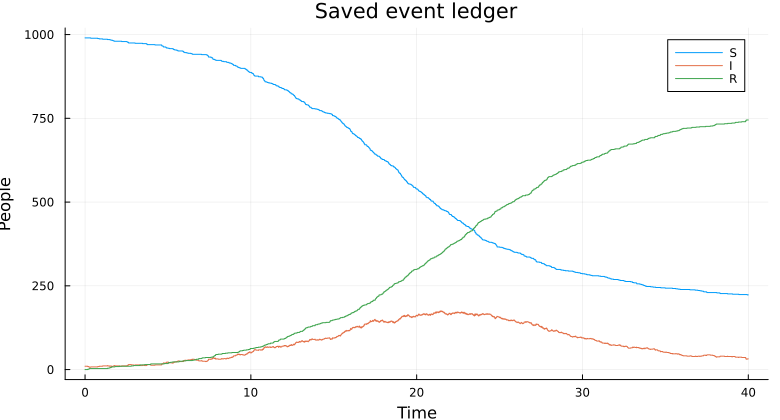

In [1]:
using DrWatson
@quickactivate "ContactEpidemics"
using ContactEpidemics.ContactProcesses
using ContactEpidemics.StudyTools
using DataFrames, CSV, Plots, Statistics


folder = datadir("sims")
files = sort(filter(name -> startswith(name,"sir_N1000_"),readdir(folder)))
isempty(files) && error("Run sir_des.jl first")
data = CSV.read(joinpath(folder,first(files)),DataFrame)
@assert all(data.S .+ data.E .+ data.I .+ data.R .== 1000)
k = argmax(data.I)
summary = DataFrame(source=[first(files)],rows=[nrow(data)],
    peak=[data.I[k]],time_peak=[data.t[k]],R_T=[last(data.R)])
save_table("csv_review",summary)
display(summary)
figure = plot(data.t,Matrix(data[:,[:S,:I,:R]]),
    label=["S" "I" "R"],xlabel="Time",ylabel="People",
    seriestype=:steppost,title="Saved event ledger")
savefig(figure,imagefile("csv-review"))
display(plot(figure; size=(780,420)))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*